In [1]:
import anndata
import torch
import stPlus

import squidpy as sq
import numpy as np
import scanpy as sc
import pandas as pd

from scipy import sparse
from sklearn.model_selection import KFold
from transpa.eval_util import calc_corr
from transpa.util import expTransImp, leiden_cluster, compute_autocorr, expLocImp
from benchmark import SpaGE_impute, Tangram_impute
import warnings
from sklearn.preprocessing import MinMaxScaler
torch.autograd.detect_anomaly()
warnings.filterwarnings('ignore')

seed = 10
device = torch.device("cuda:3") if torch.cuda.is_available() else torch.device("cpu")

In [2]:
spa_adata = sc.read_h5ad("../../data/ST/seqfish/seqfish_data.h5ad")
scrna_adata = sc.read_h5ad("../../data/scRNAseq/seqfish/scRNAseq_seqfish.h5ad")
classes, ct_list = leiden_cluster(scrna_adata)
cls_key = 'leiden'
sc.pp.normalize_total(spa_adata)
sc.pp.normalize_total(scrna_adata)
sc.pp.log1p(spa_adata)
sc.pp.log1p(scrna_adata)

var_name = scrna_adata.var_names.values.copy()
var_name[np.argmax((scrna_adata.var_names == "Prkcdbp"))] = "Cavin3"
scrna_adata.var_names = var_name

scrna_adata.obs[cls_key] = classes

In [3]:
raw_spatial_df  = pd.DataFrame(spa_adata.X.toarray(), columns=spa_adata.var_names)
raw_scrna_df    = pd.DataFrame(scrna_adata.X.toarray(), columns=scrna_adata.var_names).astype(pd.SparseDtype("float32", 0))
raw_shared_gene = np.intersect1d(raw_spatial_df.columns, raw_scrna_df.columns)
raw_spatial_df.shape, raw_scrna_df.shape, raw_shared_gene.shape,

((57536, 351), (32844, 29452), (351,))

In [4]:
spa_adata.obsm['spatial'] = np.hstack([spa_adata.obs.x_global_affine.values.reshape(-1,1), spa_adata.obs.y_global_affine.values.reshape(-1,1)])
spa_adata.obsm['spatial'] = MinMaxScaler().fit_transform(spa_adata.obsm['spatial'])
spa_adata, scrna_adata


(AnnData object with n_obs × n_vars = 57536 × 351
     obs: 'uniqueID', 'embryo', 'pos', 'z', 'x_global', 'y_global', 'x_global_affine', 'y_global_affine', 'embryo_pos', 'embryo_pos_z', 'Area', 'UMAP1', 'UMAP2', 'celltype_mapped_refined', 'segmentation_vertices_x_global_affine', 'segmentation_vertices_y_global_affine'
     uns: 'log1p'
     obsm: 'spatial'
     layers: 'normalized',
 AnnData object with n_obs × n_vars = 32844 × 29452
     obs: 'cell', 'barcode', 'sample', 'pool', 'stage', 'sequencing.batch', 'theiler', 'doub.density', 'doublet', 'cluster', 'cluster.sub', 'cluster.stage', 'cluster.theiler', 'stripped', 'celltype', 'colour', 'sizeFactor', 'leiden'
     var: 'ENSEMBL', 'SYMBOL', 'SymbolUniq'
     uns: 'log1p')

In [5]:
valid_genes = np.intersect1d(spa_adata.var_names, scrna_adata.var_names)

In [6]:
sc_expr = sparse.coo_matrix(raw_scrna_df[raw_shared_gene].values)
sp_expr = raw_spatial_df[raw_shared_gene].values
loc     = spa_adata.obsm['spatial']
sc_loc = expLocImp(sc_expr, 
            sp_expr,
            loc,
            n_neighbors=6,
            l_kernel=2,
            autocorr_method='moranI',
            mapping_lowdim=128,
            lr=1e-4, weight_decay=1e-3, n_epochs=2500,
            device=device,
            seed=seed
            ) 

scrna_adata.obsm["sc_spatial"] = sc_loc # MinMaxScaler().fit_transform(sc_loc)
         

2022-12-24 12:01:41,085 - harmonypy - INFO - Iteration 1 of 10
2022-12-24 12:03:20,481 - harmonypy - INFO - Iteration 2 of 10
2022-12-24 12:05:10,920 - harmonypy - INFO - Converged after 2 iterations
[LocImp] Epoch: 2500/2500, loss: 0.016643: 100%|██████████| 2500/2500 [05:59<00:00,  6.96it/s]


In [7]:
scrna_adata_sub = scrna_adata[:, valid_genes].copy()
scrna_adata_sub.X = scrna_adata_sub.X.toarray()
sq.gr.spatial_neighbors(scrna_adata_sub,  spatial_key="sc_spatial", key_added="sc_spatial")
sq.gr.spatial_autocorr(
    scrna_adata_sub,
    connectivity_key="sc_spatial_connectivities",
    mode="moran",
    # n_perms=100,
    n_jobs=10,
)

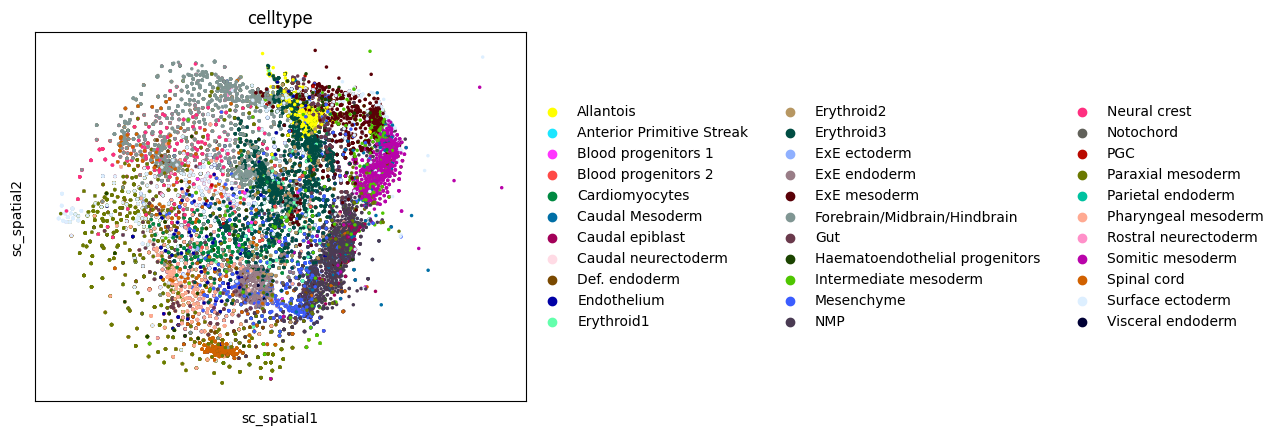

In [8]:
sc.pl.spatial(scrna_adata_sub, basis="sc_spatial", color="celltype", spot_size=0.01)   

(array([5.100e+02, 1.879e+03, 4.559e+03, 5.733e+03, 7.166e+03, 7.423e+03,
       3.477e+03, 2.089e+03, 5.000e+00, 3.000e+00]), array([0.01680514, 0.14356822, 0.2703313 , 0.39709437, 0.5238574 ,
       0.6506205 , 0.77738357, 0.9041467 , 1.0309098 , 1.1576728 ,
       1.2844359 ], dtype=float32), <BarContainer object of 10 artists>)


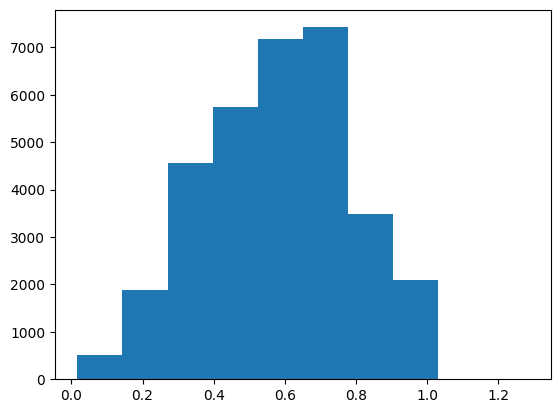

(array([ 443., 3707., 5054., 5226., 4831., 4272., 4072., 3209., 1393.,
         637.]),
 array([0.01874974, 0.11387847, 0.2090072 , 0.30413592, 0.39926466,
        0.49439338, 0.5895221 , 0.68465084, 0.77977955, 0.8749083 ,
        0.97003704], dtype=float32),
 <BarContainer object of 10 artists>)

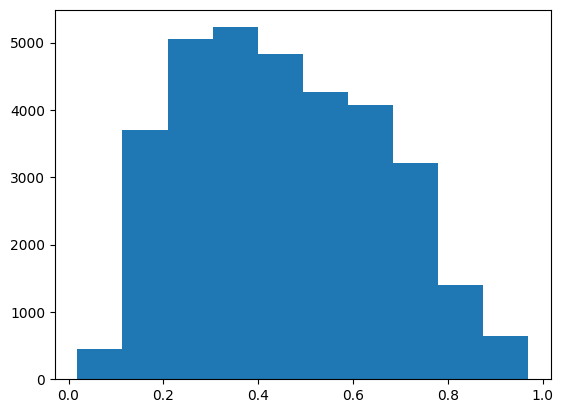

In [9]:
from matplotlib import pyplot as plt
print(plt.hist(sc_loc[:, 0])); plt.show(); plt.hist(sc_loc[:, 1])

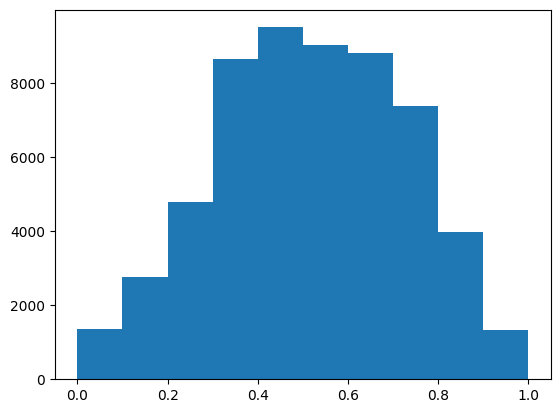

(array([1240., 5022., 7036., 8700., 7523., 5875., 6099., 6535., 7252.,
        2254.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

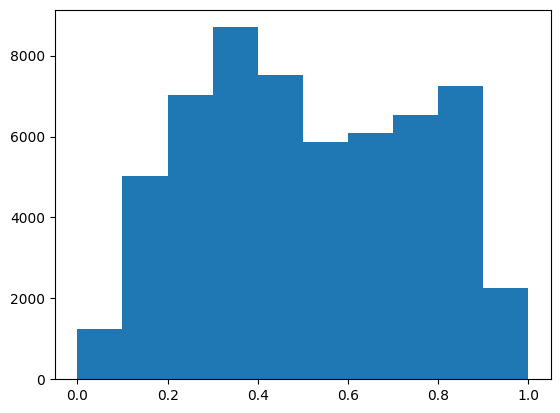

In [10]:
from matplotlib import pyplot as plt
plt.hist(spa_adata.obsm['spatial'][:, 0]); plt.show(); plt.hist(spa_adata.obsm['spatial'][:, 1])

2022-12-24 12:12:55,751 - harmonypy - INFO - Iteration 1 of 10
2022-12-24 12:15:16,928 - harmonypy - INFO - Iteration 2 of 10
2022-12-24 12:17:03,812 - harmonypy - INFO - Converged after 2 iterations


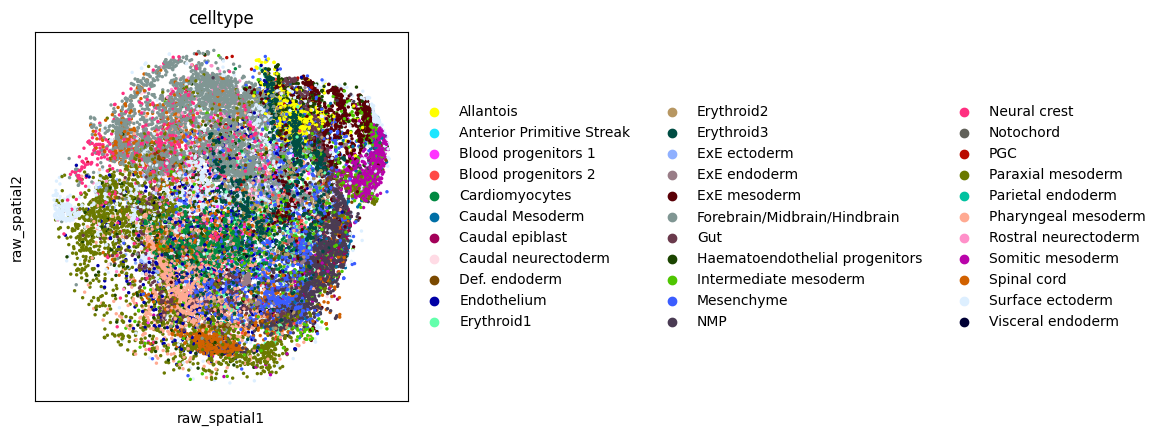

In [11]:
from sklearn.neighbors import  NearestNeighbors
from scipy.special import softmax
spa_adata_sub = spa_adata[:, valid_genes].copy()
spa_adata_sub.X = spa_adata_sub.X.toarray()
K = 2
adata = sc.AnnData(np.vstack([scrna_adata_sub.X, spa_adata_sub.X]))
adata.obs['batch'] = ["a"] * scrna_adata_sub.shape[0] + ['b'] * spa_adata_sub.shape[0]
sc.pp.pca(adata)
sc.external.pp.harmony_integrate(adata, 'batch')

emb_sc = adata.obsm['X_pca_harmony'][:sc_expr.shape[0], :]
emb_sp = adata.obsm['X_pca_harmony'][sc_expr.shape[0]:, :]
nn = NearestNeighbors(n_neighbors=K, metric='cosine', n_jobs=20)
nn.fit(emb_sp)
dists, nbs = nn.kneighbors(emb_sc, K, True)
sc_loc = np.expand_dims(softmax(-dists, axis=-1),1) @ loc[nbs]

scrna_adata_sub.obsm["raw_spatial"] = sc_loc.squeeze() # MinMaxScaler().fit_transform(sc_loc)
sc.pl.spatial(scrna_adata_sub, basis="raw_spatial", color="celltype", spot_size=0.01)


In [12]:
sq.gr.spatial_neighbors(spa_adata_sub,  spatial_key="spatial", key_added="spatial")
sq.gr.spatial_autocorr(
    spa_adata_sub,
    connectivity_key="spatial_connectivities",
    mode="moran",
    # n_perms=100,
    n_jobs=10,
)
spa_adata_sub.uns["moranI"]

In [ ]:
sq.gr.spatial_neighbors(scrna_adata_sub,  spatial_key="raw_spatial", key_added="raw_spatial")
sq.gr.spatial_autocorr(
    scrna_adata_sub,
    connectivity_key="raw_spatial_connectivities",
    mode="moran",
    # n_perms=100,
    n_jobs=10,
)
scrna_adata_sub.uns["moranI"].loc[spa_adata.var_names]

,I,pval_norm,var_norm,pval_norm_fdr_bh
gene_name,,,,
Abcc4,0.067819,0.000000e+00,0.000011,0.000000e+00
Acp5,0.536964,0.000000e+00,0.000011,0.000000e+00
Acvr1,0.006436,2.323072e-02,0.000011,2.434025e-02
Acvr2a,0.001532,3.152771e-01,0.000011,3.207602e-01
Adora2b,0.504173,0.000000e+00,0.000011,0.000000e+00
...,...,...,...,...
Wnt8a,0.094383,0.000000e+00,0.000011,0.000000e+00
Xist,0.142295,0.000000e+00,0.000011,0.000000e+00
Zfp444,0.030774,0.000000e+00,0.000011,0.000000e+00


In [ ]:
scrna_adata_cp = scrna_adata_sub.copy()
sq.gr.spatial_neighbors(scrna_adata_cp,  spatial_key="sc_spatial", key_added="sc_spatial")
sq.gr.spatial_autocorr(
    scrna_adata_cp,
    connectivity_key="sc_spatial_connectivities",
    mode="moran",
    # n_perms=100,
    n_jobs=10,
)
scrna_adata_cp.uns["moranI"].loc[spa_adata.var_names]

,I,pval_norm,var_norm,pval_norm_fdr_bh
gene_name,,,,
Abcc4,0.066971,0.000000e+00,0.00001,0.000000e+00
Acp5,0.418023,0.000000e+00,0.00001,0.000000e+00
Acvr1,0.002003,2.647570e-01,0.00001,2.709321e-01
Acvr2a,-0.000047,4.979156e-01,0.00001,4.979156e-01
Adora2b,0.480501,0.000000e+00,0.00001,0.000000e+00
...,...,...,...,...
Wnt8a,0.083181,0.000000e+00,0.00001,0.000000e+00
Xist,0.101977,0.000000e+00,0.00001,0.000000e+00
Zfp444,0.023344,2.456924e-13,0.00001,2.893893e-13


In [ ]:
from sklearn.metrics import mean_squared_error
print(mean_squared_error(spa_adata_sub.uns['moranI'].I, scrna_adata_sub.uns['moranI'].loc[spa_adata_sub.uns['moranI'].index].I))
print(mean_squared_error(spa_adata_sub.uns['moranI'].I, scrna_adata_cp.uns['moranI'].loc[spa_adata_sub.uns['moranI'].index].I))

0.03757105928567486
0.03172269798093213


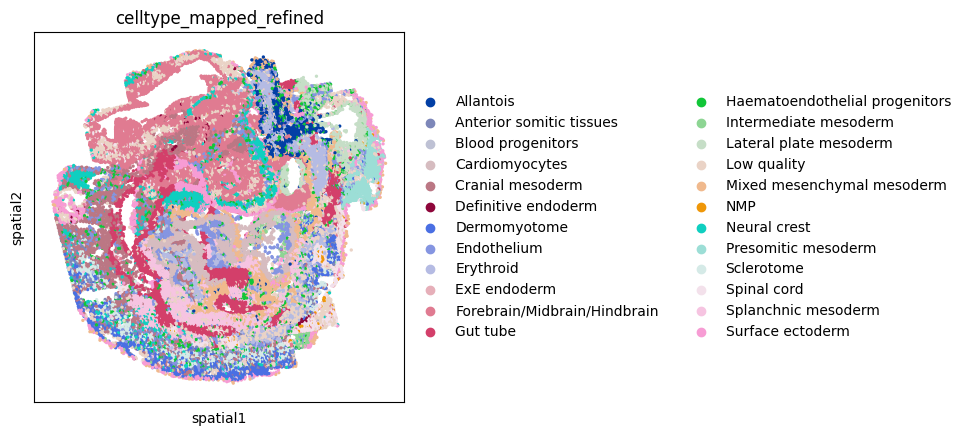

In [ ]:
sc.pl.spatial(spa_adata, color="celltype_mapped_refined", basis="spatial", spot_size=0.01)

I                   0.280169
pval_norm           0.000000
var_norm            0.000006
pval_norm_fdr_bh    0.000000
Name: Ttn, dtype: float64
AnnData object with n_obs × n_vars = 57536 × 1
    obsm: 'spatial'


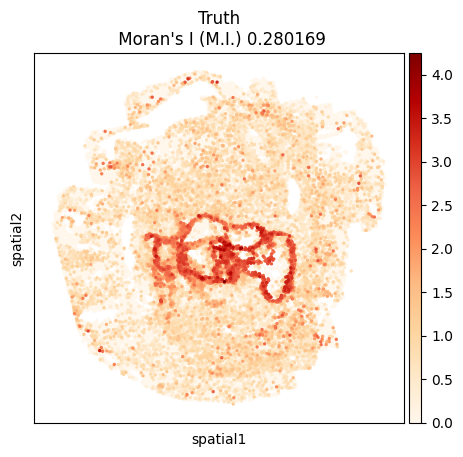

I                   0.232446
pval_norm           0.000000
var_norm            0.000011
pval_norm_fdr_bh    0.000000
Name: Ttn, dtype: float64
AnnData object with n_obs × n_vars = 32844 × 1
    obsm: 'sc_spatial', 'raw_spatial'


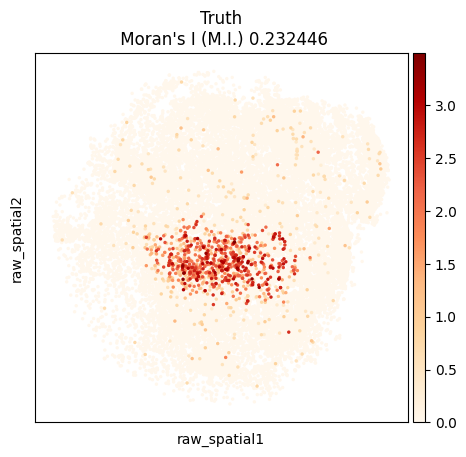

I                   0.209047
pval_norm           0.000000
var_norm            0.000010
pval_norm_fdr_bh    0.000000
Name: Ttn, dtype: float64
AnnData object with n_obs × n_vars = 32844 × 1
    obsm: 'sc_spatial', 'raw_spatial'


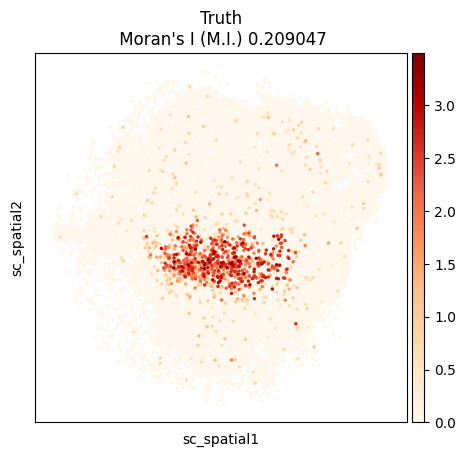

In [ ]:
def plot(gene, spa_adata, spa_key):
    exprs = [spa_adata[:, gene].X.toarray().flatten()]
    titles = [f"Truth\n Moran's I (M.I.) {spa_adata.uns['moranI'].loc[gene].I:.6f}"]
    # sc.pl.spatial(spa_adata, color=[gene], spot_size=0.1, title='Truth')
    print(spa_adata.uns['moranI'].loc[gene])
    
    tmp_adata = sc.AnnData(np.array(exprs).T)
    tmp_adata.obsm = spa_adata.obsm
    tmp_adata.var_names = titles
    
    print(tmp_adata)
    sc.pl.spatial(tmp_adata, color=titles, basis=spa_key, spot_size=0.01, title=titles, color_map='OrRd')
plot("Ttn", spa_adata_sub, spa_key='spatial')
plot("Ttn", scrna_adata_sub, spa_key='raw_spatial')
plot("Ttn", scrna_adata_cp, spa_key='sc_spatial')

I                   0.247380
pval_norm           0.000000
var_norm            0.000006
pval_norm_fdr_bh    0.000000
Name: Six3, dtype: float64
AnnData object with n_obs × n_vars = 57536 × 1
    obsm: 'spatial'


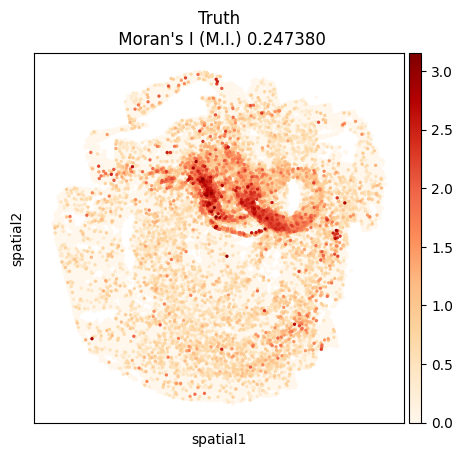

I                   0.306789
pval_norm           0.000000
var_norm            0.000011
pval_norm_fdr_bh    0.000000
Name: Six3, dtype: float64
AnnData object with n_obs × n_vars = 32844 × 1
    obsm: 'sc_spatial', 'raw_spatial'


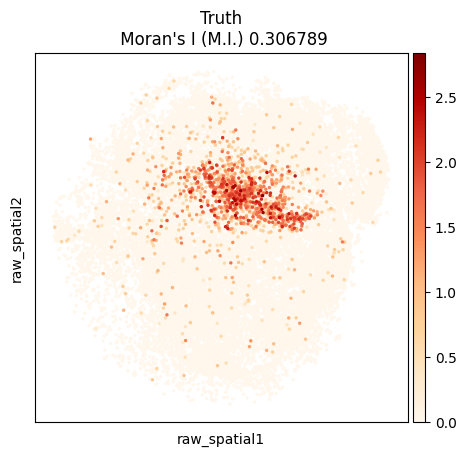

I                   0.242111
pval_norm           0.000000
var_norm            0.000010
pval_norm_fdr_bh    0.000000
Name: Six3, dtype: float64
AnnData object with n_obs × n_vars = 32844 × 1
    obsm: 'sc_spatial', 'raw_spatial'


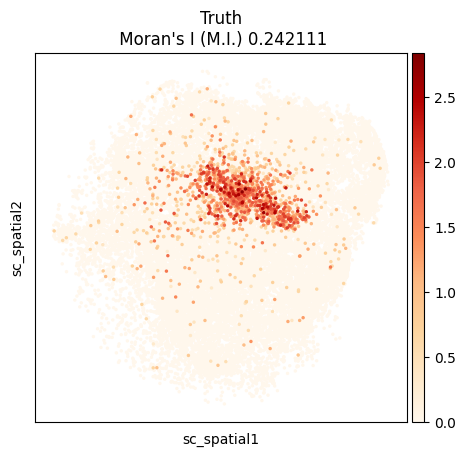

In [ ]:
plot("Six3", spa_adata_sub, spa_key='spatial')
plot("Six3", scrna_adata_sub, spa_key='raw_spatial')
plot("Six3", scrna_adata_cp, spa_key='sc_spatial')

I                   0.307169
pval_norm           0.000000
var_norm            0.000006
pval_norm_fdr_bh    0.000000
Name: Sox2, dtype: float64
AnnData object with n_obs × n_vars = 57536 × 1
    obsm: 'spatial'


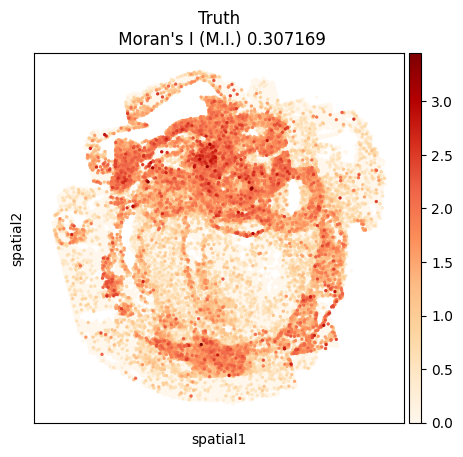

I                   0.282823
pval_norm           0.000000
var_norm            0.000011
pval_norm_fdr_bh    0.000000
Name: Sox2, dtype: float64
AnnData object with n_obs × n_vars = 32844 × 1
    obsm: 'sc_spatial', 'raw_spatial'


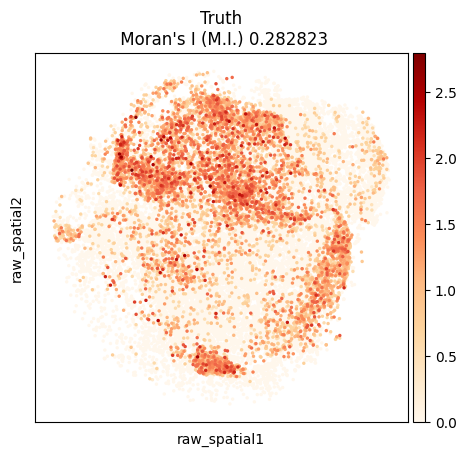

I                   0.260142
pval_norm           0.000000
var_norm            0.000010
pval_norm_fdr_bh    0.000000
Name: Sox2, dtype: float64
AnnData object with n_obs × n_vars = 32844 × 1
    obsm: 'sc_spatial', 'raw_spatial'


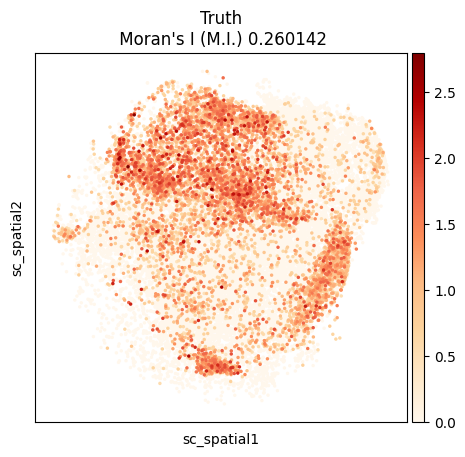

In [ ]:
plot("Sox2", spa_adata_sub, spa_key='spatial')
plot("Sox2", scrna_adata_sub, spa_key='raw_spatial')
plot("Sox2", scrna_adata_cp, spa_key='sc_spatial')